# Cylindrical cooling fin with Newton cooling boundary condition

MW260614

*Reference:* http://olivier.granier.free.fr/MOOC-Anglais/Transferts/co/ex-CCP-6-transferts.html

Let's consider a solid body B (for instance, a power transistor housing) with $T_0$ its temperature, which is higher than $T_\textrm{ext}$, temperature of the surrounding air.

In order to cool the body B, we put into place a cooling fin, made of a cylinder of $L$ length and with 
$S = \pi R^2$ its section. The cooling at the surface of the fin is modeled using Newton's law of cooling.

We will study this fin in stationary mode.

This is a classic exercise in heat transfer. It is usually approached analytically with simplifying assumptions, giving a 1D problem.

For the PyFVTool model, we use `CylindricalGrid2D(r, z)` to implement the actual Newton BCs. (In PyFVTool `Grid1D`, the cooling through the side wall would show up as a (linear) source term. Interesting for a future exercise.)

<img src="./img/cooling_fin_drawing.svg" alt="drawing of a cylindrical cooling fin attached to a body" width="576">

## to-do

- explore more fancy plotting
- add more explanations about PyFVTool subtleties (e.g. labeling 'left/right/top/bottom')*
- implement `Grid1D` model with linear source term modeling the Newton cooling of each volume element
- study appearance of radial gradient as aspect ratio decreases


## FVM model in 2D cylindrical geometry

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyfvtool as pf

We use a very thin rod and high aspect ratio because the 1D analytic  approximation (used for comparison)
is based on the assumption of a very high aspect ratio. 

For a later modeling exercise, we can of course play with the aspect ratio to investigate how the 1D analytic solution starts deviating in cases of ever lower aspect ratios.

In [2]:
Nr = 20
Nz = 100
Lr = 0.075 
Lz = 3.0

k = 50.0  # [W m-1 K-1]
h = 100.0 # [W m-2 K-1]
rhocp = 3.3e6 # 
alpha = k / rhocp

T_source = 400.0
T_ext = 280.0
rixsel = Nr//2 # index of r position whose z profile is analysed
               # Take center of domain as representative 'radially averaged" temperature 
               # along the rod
Tdev_tol = 2.0 # acceptable deviation between FVM Cylindrical2D and analytic 1D model

In [3]:
mesh = pf.CylindricalGrid2D(Nr, Nz, Lr, Lz)

In [4]:
Tcell = pf.CellVariable(mesh, 0.0)

We consider that the hot body B keeps the "bottom" (see drawing!) of the cooling fin at a constant temperature.

In [5]:
Tcell.BCs.bottom.fixedValue(T_source)

# Finally, the 'top' boundary condition setting should be irrelevant
# because the cylinder should long enough such that the extremity is 
# already at T_ext. All BC types should give same result.
# Tcell.BCs.top.fixedValue(T_ext)

The Newton cooling boundary condition on the cylinder wall is set as follows.

In [6]:
Tcell.BCs.right.newtonCooling(k, h, T_ext)

Now, we can solve the steady-state problem.

In [7]:
pf.solvePDE(Tcell, 
            [-pf.diffusionTerm(pf.FaceVariable(mesh, alpha))]);

In [8]:
rr, zz, Trrzz = Tcell.plotprofile()
# in the future, convert to xarray.DataArray for easier processing

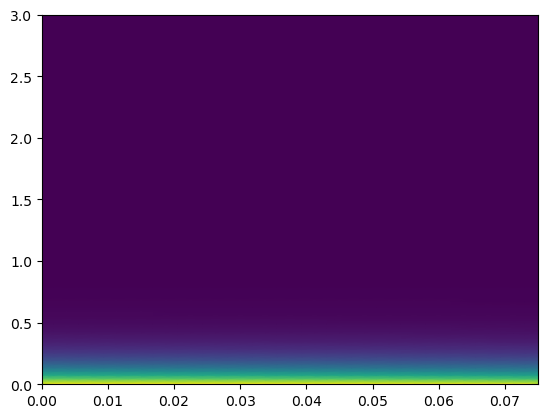

In [9]:
pf.visualizeCells(Tcell)
# in the future, come up with more fancy plotting

## Compare with analytic 1D solution

$T(z) = (T_0 - T_\textrm{ext}) e^{-z/D} + T_\textrm{ext}$

with

$D = \sqrt{\frac{kR}{2h}}$

In [10]:
D = np.sqrt((k*Lr)/(2*h))
Tan = (T_source-T_ext)*np.exp(-zz/D) + T_ext   

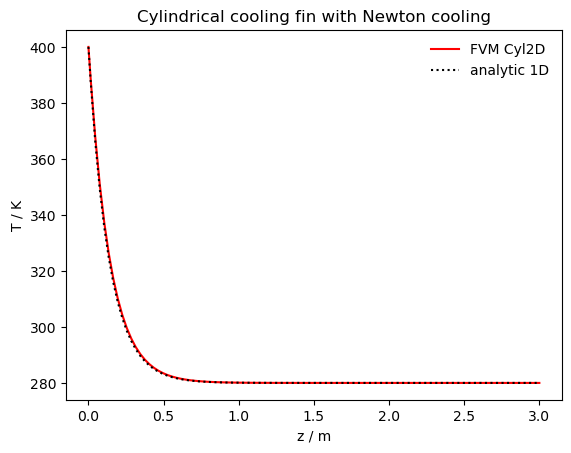

In [11]:
plt.plot(zz, Trrzz[rixsel, :], 'r-', label='FVM Cyl2D')     
plt.plot(zz, Tan, 'k:', label='analytic 1D')
plt.ylabel('T / K')
plt.xlabel('z / m')
plt.legend(frameon=False)
plt.title('Cylindrical cooling fin with Newton cooling');

In [12]:
# Check notebook calculation integrity

Tdev = Tan - Trrzz[rixsel, :]
assert np.all(abs(Tdev) < Tdev_tol),\
    "deviation beyond tolerance between Cylindrical2D FVM and analytical 1D models"